<a href="https://colab.research.google.com/github/Franklin2609/sample/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview
   Student_ID Student_Name Class  Math  Science  English  Computer
0        S001        Aarav     A    85     78.0     90.0        88
1        S002         Diya     A    72     80.0     75.0        79
2        S003        Rahul     A    91     89.0     95.0        93
3        S004        Priya     A    65     70.0     68.0        72
4        S005      Karthik     A    55     60.0     58.0        62
5        S006       Ananya     B    88     92.0     85.0        90
6        S007       Vikram     B    76     73.0     78.0        80
7        S008        Meera     B    94      NaN     91.0        95
8        S009        Arjun     B    61     67.0     64.0        69
9        S010        Nisha     B    83     81.0     86.0        84
10       S011        Rohan     C    45     52.0     50.0        48
11       S012        Sneha     C    79     85.0     82.0        81
12       S013         Ajay     C    68     72.0     70.0        74
13       S014        Kavya     C    90     88.

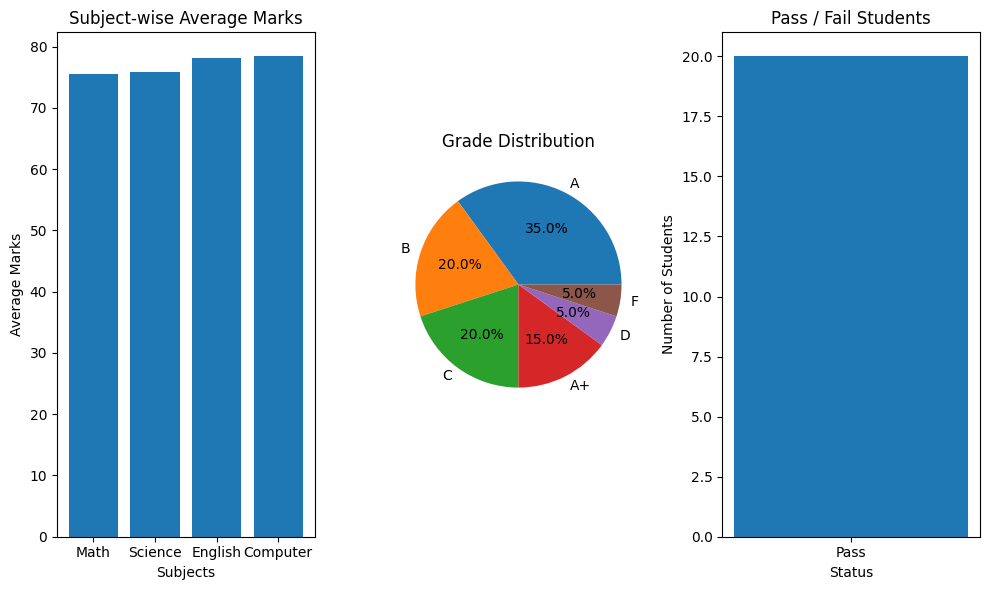

In [1]:
# STUDENT PERFORMANCE & RESULT ANALYTICS

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create Dataset

data = {
    "Student_ID":["S001","S002","S003","S004","S005","S006","S007","S008","S009","S010","S011","S012","S013","S014","S015","S016","S017","S018","S019","S020","S005"],

    "Student_Name":["Aarav","Diya","Rahul","Priya","Karthik","Ananya","Vikram","Meera","Arjun","Nisha","Rohan","Sneha","Ajay","Kavya","Manoj","Pooja","Harish","Deepa","Sanjay","Keerthana","Karthik"],

    "Class":["A","A","A","A","A","B","B","B","B","B","C","C","C","C","C","D","D","D","D","D","A"],

    "Math":[85,72,91,65,55,88,76,94,61,83,45,79,68,90,58,87,74,96,63,81,55],

    "Science":[78,80,89,70,60,92,73,np.nan,67,81,52,85,72,88,55,84,76,94,66,79,60],

    "English":[90,75,95,68,58,85,78,91,64,86,50,82,70,92,np.nan,89,72,98,61,83,58],

    "Computer":[88,79,93,72,62,90,80,95,69,84,48,81,74,91,57,86,75,97,65,82,62]
}

df = pd.DataFrame(data)

print("Dataset Preview")
print(df)

# Missing Values
print("\nMissing Values Before Cleaning")
print(df.isnull().sum())

# Fill Missing Values
df.fillna(df.mean(numeric_only=True), inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# Duplicate Records
print("\nDuplicate Rows Before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate Rows After:", df.duplicated().sum())

# Calculate Average
df["Average"] = df[["Math","Science","English","Computer"]].mean(axis=1)

print("\nAverage Marks")
print(df[["Student_Name","Average"]])

# Assign Grades
def grade(avg):
    if avg >= 90:
        return "A+"
    elif avg >= 80:
        return "A"
    elif avg >= 70:
        return "B"
    elif avg >= 60:
        return "C"
    elif avg >= 50:
        return "D"
    else:
        return "F"

df["Grade"] = df["Average"].apply(grade)

print("\nGrades")
print(df[["Student_Name","Average","Grade"]])

# Pass / Fail
df["Status"] = np.where(
    (df["Math"]>=35) &
    (df["Science"]>=35) &
    (df["English"]>=35) &
    (df["Computer"]>=35),
    "Pass","Fail"
)

print("\nPass / Fail")
print(df[["Student_Name","Status"]])

# Top 5 Students
top5 = df.sort_values(by="Average", ascending=False)

print("\nTop 5 Students")
print(top5[["Student_Name","Average","Grade"]].head())

# Subject Average
subject_avg = df[["Math","Science","English","Computer"]].mean()

print("\nSubject-wise Average")
print(subject_avg)

# Subject Average Bar Chart
plt.figure(figsize=(10,6))
plt.subplot(1,3,1)
plt.bar(subject_avg.index, subject_avg.values)
plt.title("Subject-wise Average Marks")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")

# Grade Distribution
plt.subplot(1,3,2)
grade_count = df["Grade"].value_counts()

plt.pie(grade_count, labels=grade_count.index, autopct="%1.1f%%")
plt.title("Grade Distribution")

# Pass / Fail Chart
plt.subplot(1,3,3)
status_count = df["Status"].value_counts()

plt.bar(status_count.index, status_count.values)
plt.title("Pass / Fail Students")
plt.xlabel("Status")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()
